<center><span style="font-size:35px; font-weight:bold; color:darkblue;">
    CONFORMER
</span></center>

<center><b>Speech Emotion Recognition - Dataset m01</b></center>

**Target classes:** angry, disgust, fear, sad, neutral  
**Dataset:** `data_preprocessed/data_features_m01.csv`  
**Main outputs:** `.h5`, `.pkl`, metrics `.json`, plots `.png` saved in `models/`


## Import library

In [1]:
import os
import json
import random
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, accuracy_score

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.13.0


## Data Preparation

In [2]:
# Load dataset
DATASET_PATH = "data_preprocessed/data_features_m01.csv"

df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nLabel distribution:")
print(df["label"].value_counts())

Dataset shape: (4320, 41)

Columns:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', 'label']

Label distribution:
label
sad        960
angry      960
fear       960
disgust    960
neutral    480
Name: count, dtype: int64


In [3]:
# Filter target classes
target_classes = ["angry", "disgust", "fear", "sad", "neutral"]

df = df[df["label"].isin(target_classes)].copy()
df = df.dropna().reset_index(drop=True)

print("Filtered dataset shape:", df.shape)
print("\nClass distribution after filtering:")
display(df["label"].value_counts().to_frame("count"))

# Split features and labels
X = df.drop(columns=["label"]).values.astype("float32")
y = df["label"].values

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

print("\nClasses:", list(le.classes_))
print("Number of classes:", num_classes)
print("Feature shape:", X.shape)

Filtered dataset shape: (4320, 41)

Class distribution after filtering:


,count
label,
sad,960
angry,960
fear,960
disgust,960
neutral,480



Classes: ['angry', 'disgust', 'fear', 'neutral', 'sad']
Number of classes: 5
Feature shape: (4320, 40)


In [4]:
# Train / validation / test split
# 80% train, 10% validation, 10% test
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

# Fit scaler on train only, then transform validation/test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Conformer input: (samples, timesteps, channels)
# Here each engineered acoustic feature is treated as one token/timestep.
X_train_cf = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_val_cf = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
X_test_cf = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# One-hot labels
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("Train:", X_train_cf.shape, y_train_cat.shape)
print("Validation:", X_val_cf.shape, y_val_cat.shape)
print("Test:", X_test_cf.shape, y_test_cat.shape)

Train: (3456, 40, 1) (3456, 5)
Validation: (432, 40, 1) (432, 5)
Test: (432, 40, 1) (432, 5)


In [5]:
# Declare output paths
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_NAME = "conformer"
MODEL_VERSION = "m01"

BEST_MODEL_PATH = os.path.join(MODEL_DIR, f"best_{MODEL_NAME}_model_{MODEL_VERSION}.h5")
SCALER_PATH = os.path.join(MODEL_DIR, f"scaler_{MODEL_NAME}_{MODEL_VERSION}.pkl")
LABEL_ENCODER_PATH = os.path.join(MODEL_DIR, f"label_encoder_{MODEL_NAME}_{MODEL_VERSION}.pkl")
HISTORY_PATH = os.path.join(MODEL_DIR, f"history_{MODEL_NAME}_{MODEL_VERSION}.pkl")
METRICS_PATH = os.path.join(MODEL_DIR, f"metrics_{MODEL_NAME}_{MODEL_VERSION}.json")
CM_PLOT_PATH = os.path.join(MODEL_DIR, f"confusion_matrix_{MODEL_NAME}_{MODEL_VERSION}.png")
HISTORY_PLOT_PATH = os.path.join(MODEL_DIR, f"training_history_{MODEL_NAME}_{MODEL_VERSION}.png")

print("Best model path:", BEST_MODEL_PATH)
print("Scaler path:", SCALER_PATH)
print("Label encoder path:", LABEL_ENCODER_PATH)

Best model path: models\best_conformer_model_m01.h5
Scaler path: models\scaler_conformer_m01.pkl
Label encoder path: models\label_encoder_conformer_m01.pkl


## Build model

In [6]:
# Optimized Conformer configuration
# Keep max epochs aligned with other models for fair academic comparison.
D_MODEL = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_BLOCKS = 3
CONV_KERNEL_SIZE = 7
DROPOUT_RATE = 0.25
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.03


def feed_forward_module(x, ff_dim, dropout=0.25):
    """Macaron-style feed-forward module used in Conformer."""
    residual = x

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(ff_dim, activation="swish")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(residual.shape[-1])(x)
    x = layers.Dropout(dropout)(x)

    return residual + 0.5 * x


def convolution_module(x, embed_dim, kernel_size=7, dropout=0.25):
    """Conformer convolution module: pointwise -> depthwise -> BN -> pointwise."""
    residual = x

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Conv1D(filters=2 * embed_dim, kernel_size=1, padding="same")(x)

    # GLU-style gating
    x_a, x_b = tf.split(x, num_or_size_splits=2, axis=-1)
    x = x_a * tf.nn.sigmoid(x_b)

    x = layers.SeparableConv1D(
        filters=embed_dim,
        kernel_size=kernel_size,
        padding="same",
        activation="swish"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=embed_dim, kernel_size=1, padding="same")(x)
    x = layers.Dropout(dropout)(x)

    return residual + x


def conformer_block(x, embed_dim=128, num_heads=4, ff_dim=256, kernel_size=7, dropout=0.25):
    """Conformer block: FFN -> MHSA -> Conv -> FFN -> LayerNorm."""
    # Feed-forward module 1
    x = feed_forward_module(x, ff_dim=ff_dim, dropout=dropout)

    # Multi-head self-attention module
    residual = x
    x_norm = layers.LayerNormalization(epsilon=1e-6)(x)

    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout
    )(x_norm, x_norm)

    attn = layers.Dropout(dropout)(attn)
    x = residual + attn

    # Convolution module
    x = convolution_module(
        x,
        embed_dim=embed_dim,
        kernel_size=kernel_size,
        dropout=dropout
    )

    # Feed-forward module 2
    x = feed_forward_module(x, ff_dim=ff_dim, dropout=dropout)

    return layers.LayerNormalization(epsilon=1e-6)(x)


def build_conformer_model(
    input_shape,
    num_classes,
    embed_dim=128,
    num_heads=4,
    ff_dim=256,
    num_blocks=3,
    kernel_size=7,
    dropout=0.25
):
    inputs = Input(shape=input_shape)

    # Input projection
    x = layers.Dense(embed_dim)(inputs)

    # Learnable positional embedding
    positions = tf.range(start=0, limit=input_shape[0], delta=1)
    pos_embedding = layers.Embedding(
        input_dim=input_shape[0],
        output_dim=embed_dim
    )(positions)

    x = x + pos_embedding

    # Conformer encoder blocks
    for _ in range(num_blocks):
        x = conformer_block(
            x,
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            kernel_size=kernel_size,
            dropout=dropout
        )

    # Classification head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="swish")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(64, activation="swish")(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="Optimized_Conformer_EmotionRecognition_m01"
    )

    return model


input_shape = (X_train_cf.shape[1], X_train_cf.shape[2])

model = build_conformer_model(
    input_shape=input_shape,
    num_classes=num_classes,
    embed_dim=D_MODEL,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_blocks=NUM_BLOCKS,
    kernel_size=CONV_KERNEL_SIZE,
    dropout=DROPOUT_RATE
)

# AdamW is preferred for Transformer/Conformer-style models.
try:
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
except AttributeError:
    print("AdamW is not available in this TensorFlow version. Falling back to Adam.")
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=["accuracy"]
)

model.summary()

Model: "Optimized_Conformer_EmotionRecognition_m01"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 40, 1)]              0         []                            
                                                                                                  
 dense (Dense)               (None, 40, 128)              256       ['input_1[0][0]']             
                                                                                                  
 tf.__operators__.add (TFOp  (None, 40, 128)              0         ['dense[0][0]']               
 Lambda)                                                                                          
                                                                                                  
 layer_normalization (Layer  (None, 40, 128)             

## Train model

In [7]:
# Compute softened class weights
# Using full balanced class_weight may over-amplify the minority class (neutral),
# so square-root smoothing is applied for a fairer class correction.
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    int(class_id): float(np.sqrt(weight))
    for class_id, weight in zip(np.unique(y_train), class_weights_values)
}

print("Soft class weights:")
for idx, weight in class_weights.items():
    print(f"{le.classes_[idx]}: {weight:.4f}")

Soft class weights:
angry: 0.9487
disgust: 0.9487
fear: 0.9487
neutral: 1.3416
sad: 0.9487


In [8]:
# Callbacks
checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=18,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    mode="min",
    verbose=1
)

callbacks = [checkpoint, early_stop, lr_scheduler]

history = model.fit(
    X_train_cf,
    y_train_cat,
    validation_data=(X_val_cf, y_val_cat),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

print("Training completed.")
print("Best model saved at:", BEST_MODEL_PATH)

Epoch 1/100
108/108 [==============================] - ETA: 0s - loss: 1.8664 - accuracy: 0.2393   
Epoch 1: val_accuracy improved from -inf to 0.21991, saving model to models\best_conformer_model_m01.h5
108/108 [==============================] - 39s 224ms/step - loss: 1.8664 - accuracy: 0.2393 - val_loss: 1.7636 - val_accuracy: 0.2199 - lr: 3.0000e-04
Epoch 2/100
108/108 [==============================] - ETA: 0s - loss: 1.6962 - accuracy: 0.2818 
Epoch 2: val_accuracy improved from 0.21991 to 0.25694, saving model to models\best_conformer_model_m01.h5
108/108 [==============================] - 23s 214ms/step - loss: 1.6962 - accuracy: 0.2818 - val_loss: 1.7891 - val_accuracy: 0.2569 - lr: 3.0000e-04
Epoch 3/100
108/108 [==============================] - ETA: 0s - loss: 1.6113 - accuracy: 0.3148 
Epoch 3: val_accuracy improved from 0.25694 to 0.27778, saving model to models\best_conformer_model_m01.h5
108/108 [==============================] - 22s 207ms/step - loss: 1.6113 - accuracy:

## Predict on test set

In [9]:
# Load the best checkpoint before final evaluation
best_model = load_model(BEST_MODEL_PATH)

y_pred_probs = best_model.predict(X_test_cf, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

test_loss, test_accuracy = best_model.evaluate(X_test_cf, y_test_cat, verbose=0)

print("Test Accuracy:", round(float(test_accuracy), 4))
print("Test Loss:", round(float(test_loss), 4))

Test Accuracy: 0.8727
Test Loss: 0.5288


## Evaluation

In [10]:
# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))

# Cohen's Kappa
kappa = cohen_kappa_score(y_true, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")

Classification Report:
              precision    recall  f1-score   support

       angry     0.9750    0.8125    0.8864        96
     disgust     0.8367    0.8542    0.8454        96
        fear     0.8544    0.9167    0.8844        96
     neutral     0.8182    0.9375    0.8738        48
         sad     0.8750    0.8750    0.8750        96

    accuracy                         0.8727       432
   macro avg     0.8719    0.8792    0.8730       432
weighted avg     0.8778    0.8727    0.8729       432

Cohen's Kappa: 0.8392


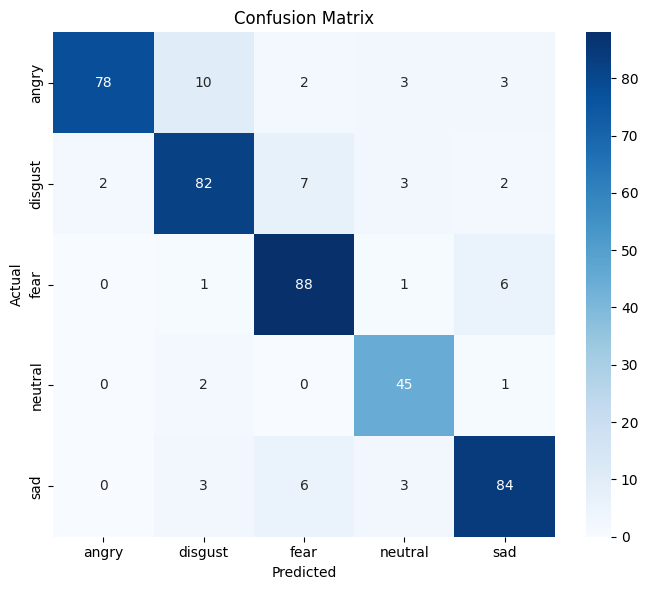

Confusion matrix plot saved at: models\confusion_matrix_conformer_m01.png


In [11]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(CM_PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix plot saved at:", CM_PLOT_PATH)

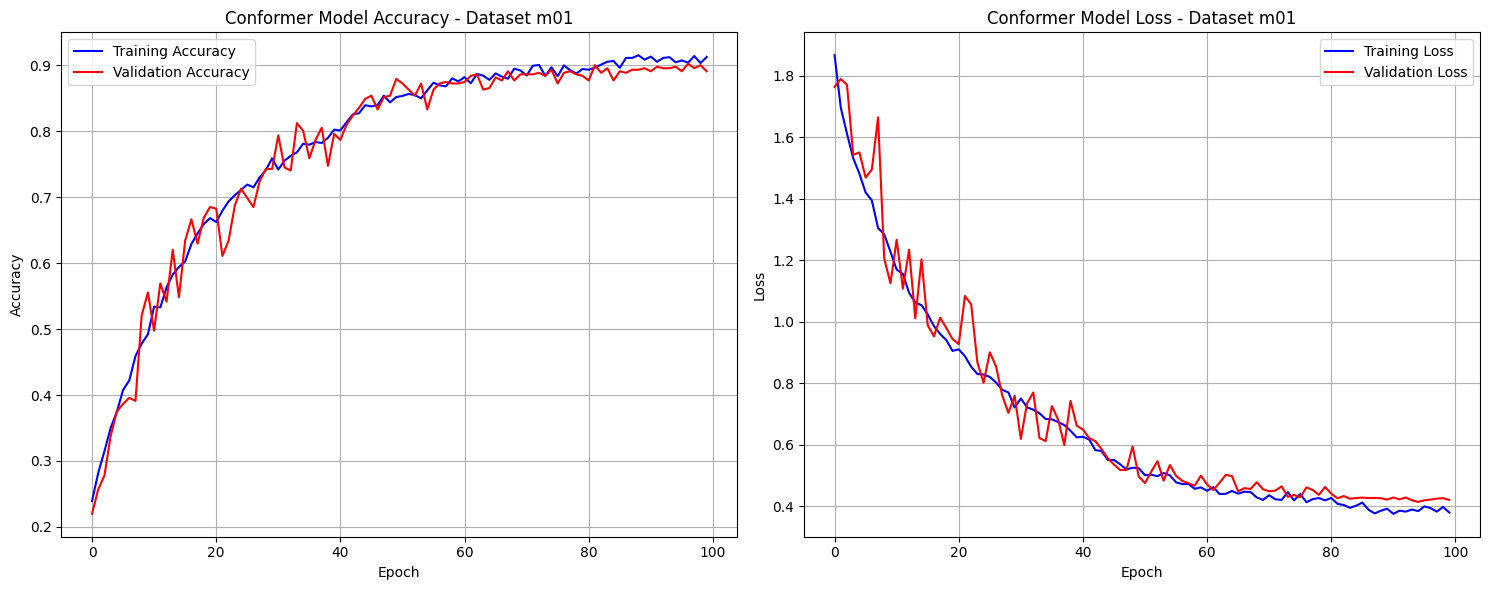

Training history plot saved at: models\training_history_conformer_m01.png


In [12]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('Conformer Model Accuracy - Dataset m01')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('Conformer Model Loss - Dataset m01')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(HISTORY_PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Training history plot saved at:", HISTORY_PLOT_PATH)

## Save preprocessing objects and final metrics

In [13]:
# Save preprocessing objects
joblib.dump(scaler, SCALER_PATH)
joblib.dump(le, LABEL_ENCODER_PATH)
joblib.dump(history.history, HISTORY_PATH)

metrics = {
    "model": "Optimized Conformer",
    "dataset": DATASET_PATH,
    "version": MODEL_VERSION,
    "classes": list(le.classes_),
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "cohen_kappa": float(kappa),
    "epochs_trained": len(history.history["accuracy"]),
    "hyperparameters": {
        "d_model": D_MODEL,
        "num_heads": NUM_HEADS,
        "ff_dim": FF_DIM,
        "num_blocks": NUM_BLOCKS,
        "conv_kernel_size": CONV_KERNEL_SIZE,
        "dropout_rate": DROPOUT_RATE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "label_smoothing": LABEL_SMOOTHING,
        "batch_size": 32,
        "max_epochs": 100,
        "class_weight": "sqrt_balanced"
    },
    "best_model_path": BEST_MODEL_PATH,
    "scaler_path": SCALER_PATH,
    "label_encoder_path": LABEL_ENCODER_PATH,
    "history_path": HISTORY_PATH,
    "confusion_matrix_plot_path": CM_PLOT_PATH,
    "training_history_plot_path": HISTORY_PLOT_PATH
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

print("Saved files:")
print("-", BEST_MODEL_PATH)
print("-", SCALER_PATH)
print("-", LABEL_ENCODER_PATH)
print("-", HISTORY_PATH)
print("-", METRICS_PATH)
print("-", CM_PLOT_PATH)
print("-", HISTORY_PLOT_PATH)

if hasattr(scaler, "mean_"):
    print("Scaler mean[0]:", round(float(scaler.mean_[0]), 2))

print("Classes:", list(le.classes_))

Saved files:
- models\best_conformer_model_m01.h5
- models\scaler_conformer_m01.pkl
- models\label_encoder_conformer_m01.pkl
- models\history_conformer_m01.pkl
- models\metrics_conformer_m01.json
- models\confusion_matrix_conformer_m01.png
- models\training_history_conformer_m01.png
Scaler mean[0]: -528.12
Classes: ['angry', 'disgust', 'fear', 'neutral', 'sad']


## Final Results Summary

In [14]:
print("\nFINAL RESULTS SUMMARY - Conformer m01")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Epochs Trained: {len(history.history['accuracy'])}")
print(f"Dataset: {DATASET_PATH}")
print(f"Classes: {', '.join(le.classes_)}")
print(f"Best model: {BEST_MODEL_PATH}")
print(f"Scaler: {SCALER_PATH}")
print(f"Label encoder: {LABEL_ENCODER_PATH}")


FINAL RESULTS SUMMARY - Conformer m01
Test Accuracy: 0.8727
Test Loss: 0.5288
Cohen's Kappa: 0.8392
Epochs Trained: 100
Dataset: data_preprocessed/data_features_m01.csv
Classes: angry, disgust, fear, neutral, sad
Best model: models\best_conformer_model_m01.h5
Scaler: models\scaler_conformer_m01.pkl
Label encoder: models\label_encoder_conformer_m01.pkl
